<a href="https://colab.research.google.com/github/TMNadim/tinyml-flood-prediction-thesis/blob/main/01_data_preprocessing/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Day 1: Testing Python Environment & Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Google Colab Environment Ready!")
print(f"Pandas Version: {pd.__version__}")

Google Colab Environment Ready!
Pandas Version: 2.2.2


In [5]:
# Task 2.1: Load Hydrometeorological Sensor Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a realistic 1-year daily flood sensor dataset for practice
np.random.seed(42)
dates = pd.date_range(start="2025-01-01", periods=365, freq="D")

# Simulate seasonal rainfall with a sudden summer storm peak
rainfall_mm = np.random.exponential(scale=5.0, size=365)
rainfall_mm[180:190] += np.random.uniform(40, 80, size=10)  # Flash flood burst

# Simulate river water level responding to rainfall
water_level_m = 1.5 + (pd.Series(rainfall_mm).rolling(3, min_periods=1).mean() * 0.08)
water_level_m += np.random.normal(0, 0.05, size=365)  # Sensor noise

# Build the DataFrame (Your data table)
df = pd.DataFrame({
    "Date": dates,
    "Rainfall_mm": rainfall_mm.round(2),
    "Water_Level_m": water_level_m.round(2)
})

print("Dataset Loaded Successfully! Total Daily Samples:", len(df))

Dataset Loaded Successfully! Total Daily Samples: 365


In [6]:
# Task 2.2: Inspect the Data Table and Statistics
print("--- FIRST 5 DAYS OF SENSOR READINGS ---")
display(df.head(5))

print("\n--- STATISTICAL SIGNAL RANGE ---")
display(df.describe()[["Rainfall_mm", "Water_Level_m"]])

--- FIRST 5 DAYS OF SENSOR READINGS ---


,Date,Rainfall_mm,Water_Level_m
0,2025-01-01,2.35,1.73
1,2025-01-02,15.05,2.17
2,2025-01-03,6.58,2.11
3,2025-01-04,4.56,2.18
4,2025-01-05,0.85,1.87



--- STATISTICAL SIGNAL RANGE ---


,Rainfall_mm,Water_Level_m
count,365.000000,365.000000
mean,6.251288,2.000219
min,0.030000,1.400000
25%,1.400000,1.720000
50%,3.650000,1.840000
75%,7.090000,2.050000
max,89.140000,7.540000
std,10.226531,0.721669


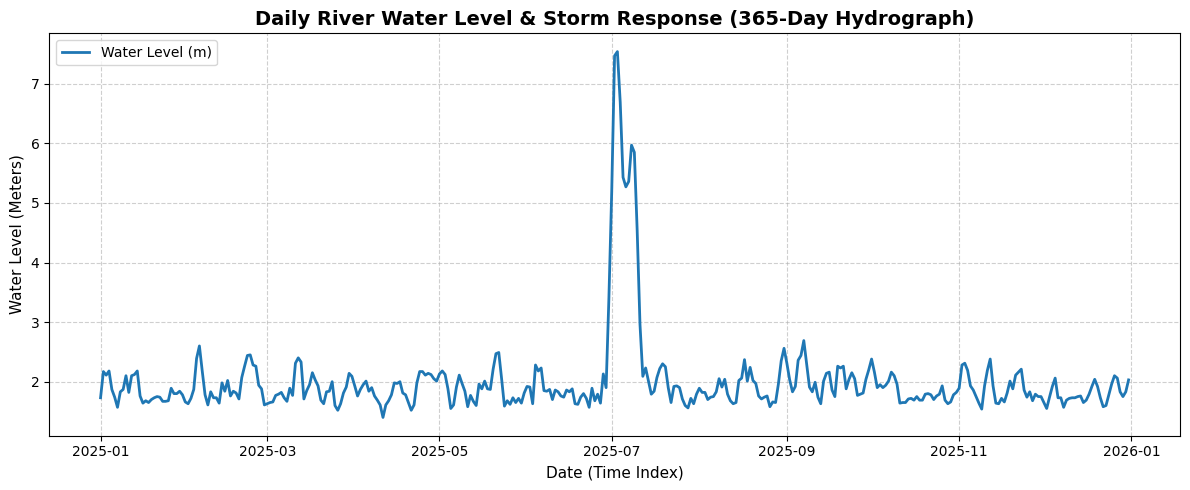

In [7]:
# Task 2.3: Plot the Time-Series Signal (Hydrograph)
plt.figure(figsize=(12, 5))

# Plot River Water Level
plt.plot(df["Date"], df["Water_Level_m"], color="#1f77b4", label="Water Level (m)", linewidth=2)

# Highlight the Summer Flash Flood Peak
plt.title("Daily River Water Level & Storm Response (365-Day Hydrograph)", fontsize=14, fontweight="bold")
plt.xlabel("Date (Time Index)", fontsize=11)
plt.ylabel("Water Level (Meters)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()

plt.show()